The goal of this project is to determine whether fighter statistics can be used to predict the outcome of a UFC fight. Using a dataset of past fights, we focused on pre-fight statistics such as age, reach, height, and performance metrics.

The main question is: can we use these features to predict the outcome of a fight?

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/large_dataset.csv")
df.head()

print(df.shape)
print(df.columns)
df.isna().sum()



(7439, 95)
Index(['event_name', 'r_fighter', 'b_fighter', 'winner', 'weight_class',
       'is_title_bout', 'gender', 'method', 'finish_round', 'total_rounds',
       'time_sec', 'referee', 'r_kd', 'r_sig_str', 'r_sig_str_att',
       'r_sig_str_acc', 'r_str', 'r_str_att', 'r_str_acc', 'r_td', 'r_td_att',
       'r_td_acc', 'r_sub_att', 'r_rev', 'r_ctrl_sec', 'r_wins_total',
       'r_losses_total', 'r_age', 'r_height', 'r_weight', 'r_reach',
       'r_stance', 'r_SLpM_total', 'r_SApM_total', 'r_sig_str_acc_total',
       'r_td_acc_total', 'r_str_def_total', 'r_td_def_total', 'r_sub_avg',
       'r_td_avg', 'b_kd', 'b_sig_str', 'b_sig_str_att', 'b_sig_str_acc',
       'b_str', 'b_str_att', 'b_str_acc', 'b_td', 'b_td_att', 'b_td_acc',
       'b_sub_att', 'b_rev', 'b_ctrl_sec', 'b_wins_total', 'b_losses_total',
       'b_age', 'b_height', 'b_weight', 'b_reach', 'b_stance', 'b_SLpM_total',
       'b_SApM_total', 'b_sig_str_acc_total', 'b_td_acc_total',
       'b_str_def_total', 'b_td_def_

,0
event_name,0
r_fighter,0
b_fighter,0
winner,0
weight_class,0
...,...
td_acc_total_diff,0
str_def_total_diff,0
td_def_total_diff,0
sub_avg_diff,0


In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
# Make a smaller dataframe with only the columns we want to use

ufc = df[[
    "r_fighter", "b_fighter", "winner",
    "r_wins_total", "r_losses_total", "r_age", "r_height", "r_weight", "r_reach",
    "r_SLpM_total", "r_SApM_total", "r_sig_str_acc_total", "r_td_acc_total",
    "r_str_def_total", "r_td_def_total", "r_sub_avg", "r_td_avg",
    "b_wins_total", "b_losses_total", "b_age", "b_height", "b_weight", "b_reach",
    "b_SLpM_total", "b_SApM_total", "b_sig_str_acc_total", "b_td_acc_total",
    "b_str_def_total", "b_td_def_total", "b_sub_avg", "b_td_avg"
]]

# Drop rows with missing values
ufc = ufc.dropna()

# Make the target column
# 1 means the red fighter won, 0 means the blue fighter won
ufc["red_win"] = ufc["winner"] == "Red"
ufc["red_win"] = ufc["red_win"].astype(int)

# Create comparison columns
ufc["wins_diff"] = ufc["r_wins_total"] - ufc["b_wins_total"]
ufc["losses_diff"] = ufc["r_losses_total"] - ufc["b_losses_total"]
ufc["age_diff"] = ufc["r_age"] - ufc["b_age"]
ufc["height_diff"] = ufc["r_height"] - ufc["b_height"]
ufc["weight_diff"] = ufc["r_weight"] - ufc["b_weight"]
ufc["reach_diff"] = ufc["r_reach"] - ufc["b_reach"]

ufc["SLpM_diff"] = ufc["r_SLpM_total"] - ufc["b_SLpM_total"]
ufc["SApM_diff"] = ufc["r_SApM_total"] - ufc["b_SApM_total"]
ufc["sig_str_acc_diff"] = ufc["r_sig_str_acc_total"] - ufc["b_sig_str_acc_total"]
ufc["td_acc_diff"] = ufc["r_td_acc_total"] - ufc["b_td_acc_total"]
ufc["str_def_diff"] = ufc["r_str_def_total"] - ufc["b_str_def_total"]
ufc["td_def_diff"] = ufc["r_td_def_total"] - ufc["b_td_def_total"]
ufc["sub_avg_diff"] = ufc["r_sub_avg"] - ufc["b_sub_avg"]
ufc["td_avg_diff"] = ufc["r_td_avg"] - ufc["b_td_avg"]

# Check the cleaned dataframe
ufc.head()

,r_fighter,b_fighter,winner,r_wins_total,r_losses_total,r_age,r_height,r_weight,r_reach,r_SLpM_total,...,weight_diff,reach_diff,SLpM_diff,SApM_diff,sig_str_acc_diff,td_acc_diff,str_def_diff,td_def_diff,sub_avg_diff,td_avg_diff
0,Amanda Ribas,Rose Namajunas,Blue,12,5,30.0,160.02,56.70,167.64,4.63,...,0.00,2.54,0.94,-0.11,-0.01,0.04,-0.02,0.26,0.2,0.69
1,Karl Williams,Justin Tafa,Red,10,1,34.0,190.50,106.59,200.66,2.87,...,-13.16,12.70,-1.22,-3.32,-0.02,0.50,0.13,0.50,0.2,4.75
2,Edmen Shahbazyan,AJ Dobson,Red,13,4,26.0,187.96,83.91,190.50,3.60,...,0.00,-2.54,-0.69,-1.22,0.06,-0.37,-0.01,-0.02,0.3,0.57
3,Payton Talbott,Cameron Saaiman,Red,8,0,25.0,177.80,61.23,177.80,8.05,...,0.00,7.62,2.73,-0.60,0.08,-0.28,0.00,0.43,-0.2,-0.91
4,Billy Quarantillo,Youssef Zalal,Blue,18,6,35.0,177.80,65.77,177.80,7.36,...,0.00,-5.08,4.48,3.84,0.07,-0.11,-0.22,0.01,-0.2,-1.04


In [41]:
print(ufc.shape)
ufc[["r_fighter", "b_fighter", "winner", "red_win", "age_diff", "height_diff", "reach_diff"]].head()

(6393, 46)


,r_fighter,b_fighter,winner,red_win,age_diff,height_diff,reach_diff
0,Amanda Ribas,Rose Namajunas,Blue,0,-1.0,-5.08,2.54
1,Karl Williams,Justin Tafa,Red,1,4.0,7.62,12.70
2,Edmen Shahbazyan,AJ Dobson,Red,1,-6.0,2.54,-2.54
3,Payton Talbott,Cameron Saaiman,Red,1,2.0,5.08,7.62
4,Billy Quarantillo,Youssef Zalal,Blue,0,8.0,0.00,-5.08


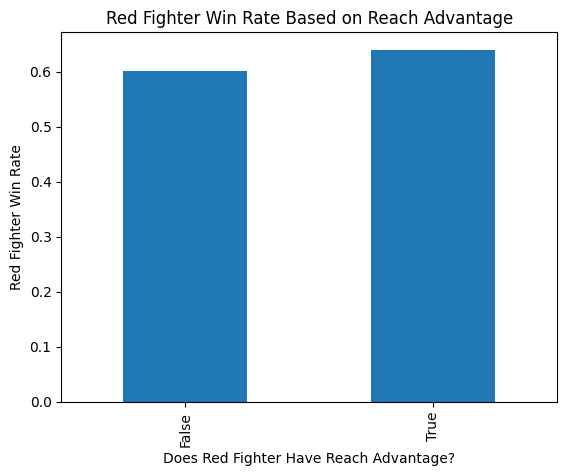

In [42]:
# First visualization: Does reach advantage seem to matter?

reach_win_rate = ufc.groupby(ufc["reach_diff"] > 0)["red_win"].mean()

reach_win_rate.plot(kind="bar")
plt.xlabel("Does Red Fighter Have Reach Advantage?")
plt.ylabel("Red Fighter Win Rate")
plt.title("Red Fighter Win Rate Based on Reach Advantage")
plt.show()

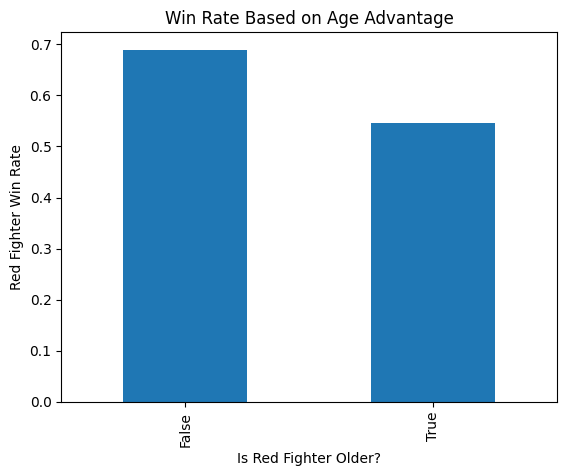

In [43]:
# Second visualization: Does age seem to matter?
age_win_rate = ufc.groupby(ufc["age_diff"] > 0)["red_win"].mean()

age_win_rate.plot(kind="bar")
plt.xlabel("Is Red Fighter Older?")
plt.ylabel("Red Fighter Win Rate")
plt.title("Win Rate Based on Age Advantage")
plt.show()

In [45]:
# Feature columns (only the diffs we made)
feature_cols = [
    "wins_diff", "losses_diff", "age_diff", "height_diff", "weight_diff", "reach_diff",
    "SLpM_diff", "SApM_diff", "sig_str_acc_diff", "td_acc_diff",
    "str_def_diff", "td_def_diff", "sub_avg_diff", "td_avg_diff"
]

X = ufc[feature_cols]
y = ufc["red_win"]


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 41
)

#Scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
#Creating KNN model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [47]:
#Making predictions and checking accuracy
from sklearn.metrics import accuracy_score

y_pred = knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("KNN Accuracy:", accuracy)

KNN Accuracy: 0.6505082095387021


In [48]:
#Tune K for KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = []
accuracies = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    k_values.append(k)
    accuracies.append(acc)

for i in range(len(k_values)):
    print("k =", k_values[i], "accuracy =", accuracies[i])

k = 1 accuracy = 0.6059421422986708
k = 2 accuracy = 0.5574667709147771
k = 3 accuracy = 0.619233776387803
k = 4 accuracy = 0.6012509773260359
k = 5 accuracy = 0.6505082095387021
k = 6 accuracy = 0.6309616888193902
k = 7 accuracy = 0.6591086786551994
k = 8 accuracy = 0.6489444878811571
k = 9 accuracy = 0.6622361219702892
k = 10 accuracy = 0.6520719311962471
k = 11 accuracy = 0.656763096168882
k = 12 accuracy = 0.6708365910867865
k = 13 accuracy = 0.6661454261141517
k = 14 accuracy = 0.6692728694292416
k = 15 accuracy = 0.6770914777169664
k = 16 accuracy = 0.6810007818608288
k = 17 accuracy = 0.6770914777169664
k = 18 accuracy = 0.6872556684910086
k = 19 accuracy = 0.6763096168881939
k = 20 accuracy = 0.6724003127443315


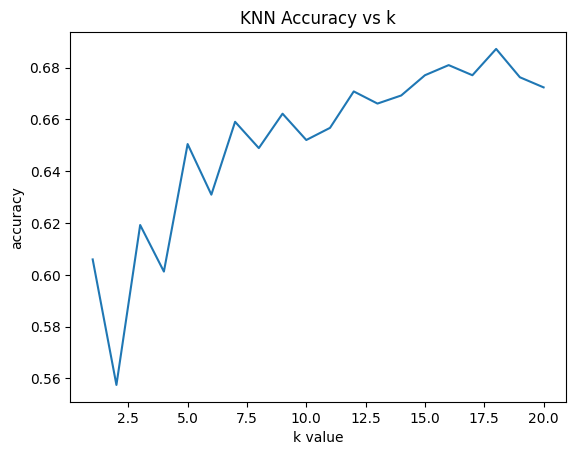

In [49]:
plt.plot(k_values, accuracies)
plt.xlabel("k value")
plt.ylabel("accuracy")
plt.title("KNN Accuracy vs k")
plt.show()

In [50]:
best_k = 18  # Looking at the graph, k vlaue of 18 provides best accuracy

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.6872556684910086


In [51]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
log_accuracy = accuracy_score(y_test, log_pred)
print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.7107114933541829


In [52]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression Accuracy:", log_accuracy)

KNN Accuracy: 0.6872556684910086
Logistic Regression Accuracy: 0.7107114933541829


In [53]:
# Fight predictor using fight number
# Using logistic regression instead of knn because it gave better accuracy score
fight_number = 10

one_fight = X_test.iloc[[fight_number]]
one_fight_scaled = scaler.transform(one_fight)

prediction = log_model.predict(one_fight_scaled)
probability = log_model.predict_proba(one_fight_scaled)

print("Fight features:")
print(one_fight)

print("Chance Blue wins:", probability[0][0])
print("Chance Red wins:", probability[0][1])

if prediction[0] == 1:
    print("Model predicts: Red fighter has the edge")
else:
    print("Model predicts: Blue fighter has the edge")

Fight features:
     wins_diff  losses_diff  age_diff  height_diff  weight_diff  reach_diff  \
134          1            2      -6.0        -2.54          0.0         0.0   

     SLpM_diff  SApM_diff  sig_str_acc_diff  td_acc_diff  str_def_diff  \
134      -0.31       1.17             -0.15          0.1         -0.08   

     td_def_diff  sub_avg_diff  td_avg_diff  
134         0.03           0.1         0.38  
Chance Blue wins: 0.4640808216086406
Chance Red wins: 0.5359191783913594
Model predicts: Red fighter has the edge
